# H-015 · Entry extremity scores (no copula)

Arms: `trad_z` | `v1_roll_asym` | `v1_ewm_asym` | `v2_ou` | `v3_hmm_innov`.
HMM is fit on **fold-train** spread changes only; live filter is PIT.

Type `ENTRY_STAR`. This is the last hyp in the stack — still no `s2_strategy.py`.


## 0. Imports & Config


In [1]:
import os
import sys

import matplotlib.pyplot as plt
import pandas as pd

ROOT = os.path.abspath(os.getcwd())
while not os.path.isdir(os.path.join(ROOT, "01_data", "ingestion")):
    parent = os.path.dirname(ROOT)
    if parent == ROOT:
        break
    ROOT = parent
if ROOT not in sys.path:
    sys.path.insert(0, ROOT)

from backtest.s2_coint.report import (
    fold_table,
    fold_val_metrics,
    load_star_stack,
    median_sharpe_hint,
    plot_fold_boxplots,
    require_star,
    save_star_stack,
    write_tearsheet_pdf,
)
from backtest.s2_coint.research import (
    ARTIFACTS_DIR,
    DEFAULT_STAR_STACK,
    config_from_stack,
    is_end_for_stack,
    load_s1_weekly,
    frozen_pairs_for_universe,
    load_universe_panels,
    lookbacks_for_bar,
    overlay_kalman_hedge,
    overlay_ols_hedge,
    repo_root,
    split_is_oos,
    tearsheet_path,
)
from backtest.s2_coint.runner import run_s2_backtest
from backtest.s2_coint.walkforward import embargo_bars_for_config, make_s2_folds
from strategies.s2_coint.config import S2SimConfig

STAR_PATH = DEFAULT_STAR_STACK
TEARSHEET_DIR = ARTIFACTS_DIR
stack = load_star_stack(STAR_PATH)
# Universe from H-001. PAIRS_STAR is only populated when BOOK_STAR = freeze (H-004);
# otherwise fall back to the ranked frozen book written by H-001.
require_star("UNIVERSE_STAR", stack.get("UNIVERSE_STAR"))
UNIVERSE = str(stack["UNIVERSE_STAR"])
PAIRS_STAR = list(stack.get("PAIRS_STAR") or frozen_pairs_for_universe(UNIVERSE, "1d", root=ROOT))
print("stack keys:", sorted(stack))
print("UNIVERSE", UNIVERSE, "PAIRS", PAIRS_STAR)


stack keys: ['ADF_WINDOW_STAR', 'BAR_STAR', 'BOOK_STAR', 'BREAK_STAR', 'CORR_GATE_STAR', 'ENTRY_Z_STAR', 'EXIT_STAR', 'HEDGE_STAR', 'HL_GATE_STAR', 'KALMAN_DELTA_STAR', 'OLS_WINDOW_STAR', 'OVERLAP_STAR', 'PAIRS_STAR', 'RESEARCH_IS_END_STAR', 'SIZE_STAR', 'TREND_STAR', 'UNIVERSE_STAR', 'VOL_STAR', 'Z_WINDOW_MODE_STAR', 'Z_WINDOW_STAR']
UNIVERSE D PAIRS ['WSO|WSO.B', 'HEI|HEI.A', 'NWS|NWSA']


## 1. Load frozen panel / PAIRS_STAR


In [2]:
require_star("BAR_STAR", stack.get("BAR_STAR"))
BAR = str(stack["BAR_STAR"])
train, full = load_universe_panels(UNIVERSE, BAR, PAIRS_STAR, root=ROOT)
lb = lookbacks_for_bar(
    BAR,
    ols_days=int(stack["OLS_WINDOW_STAR"]) if stack.get("OLS_WINDOW_STAR") not in (None, "") else None,
    z_days=int(stack["Z_WINDOW_STAR"]) if stack.get("Z_WINDOW_STAR") not in (None, "") else None,
    adf_days=int(stack["ADF_WINDOW_STAR"]) if stack.get("ADF_WINDOW_STAR") not in (None, "") else None,
)
train = overlay_ols_hedge(
    train,
    ols_window=lb["ols_window"],
    z_window=lb["z_window"],
    hl_window=lb["hl_window"],
    adf_window=lb["adf_window"],
)
full = overlay_ols_hedge(
    full,
    ols_window=lb["ols_window"],
    z_window=lb["z_window"],
    hl_window=lb["hl_window"],
    adf_window=lb["adf_window"],
)
if stack.get("HEDGE_STAR") == "kalman":
    kf_delta = stack["KALMAN_DELTA_STAR"]
    train = overlay_kalman_hedge(
        train,
        burn_in=lb["kalman_burn_in"],
        z_window=lb["z_window"],
        hl_window=lb["hl_window"],
        adf_window=lb["adf_window"],
        delta=kf_delta,
    )
    full = overlay_kalman_hedge(
        full,
        burn_in=lb["kalman_burn_in"],
        z_window=lb["z_window"],
        hl_window=lb["hl_window"],
        adf_window=lb["adf_window"],
        delta=kf_delta,
    )

is_end = is_end_for_stack(stack, full if BAR == "1h" else train)
if BAR == "1d":
    is_panel, oos_panel = train.copy(), full.loc[pd.to_datetime(full["date"]) > is_end].copy()
else:
    is_panel, oos_panel = split_is_oos(full, is_end=is_end)
s1_weekly = load_s1_weekly(ROOT)
print("bar", BAR, "is_end", is_end, "IS rows", len(is_panel), "OOS rows", len(oos_panel))
is_panel.head()


bar 1d is_end 2021-12-31 00:00:00 IS rows 16177 OOS rows 3492


,date,pair_id,ticker_y,ticker_x,open_y,high_y,low_y,close_y,open_x,high_x,low_x,close_x,alpha,beta,spread,z,half_life,adf_pvalue,variance_jump
0,1990-01-02,WSO|WSO.B,WSO,WSO.B,1.112374,1.112374,1.112374,1.112374,1.068989,1.068989,1.068989,1.068989,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1990-01-03,WSO|WSO.B,WSO,WSO.B,1.082310,1.082310,1.082310,1.082310,1.068989,1.068989,1.068989,1.068989,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,1990-01-04,WSO|WSO.B,WSO,WSO.B,1.082310,1.082310,1.082310,1.082310,1.068989,1.068989,1.068989,1.068989,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,1990-01-05,WSO|WSO.B,WSO,WSO.B,1.082310,1.082310,1.082310,1.082310,1.068989,1.068989,1.068989,1.068989,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,1990-01-08,WSO|WSO.B,WSO,WSO.B,1.082310,1.082310,1.082310,1.082310,1.068989,1.068989,1.068989,1.068989,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 2. Attach this-hyp columns


In [3]:
panel = is_panel.copy()
print(panel.columns.tolist())
panel.head()


['date', 'pair_id', 'ticker_y', 'ticker_x', 'open_y', 'high_y', 'low_y', 'close_y', 'open_x', 'high_x', 'low_x', 'close_x', 'alpha', 'beta', 'spread', 'z', 'half_life', 'adf_pvalue', 'variance_jump']


,date,pair_id,ticker_y,ticker_x,open_y,high_y,low_y,close_y,open_x,high_x,low_x,close_x,alpha,beta,spread,z,half_life,adf_pvalue,variance_jump
0,1990-01-02,WSO|WSO.B,WSO,WSO.B,1.112374,1.112374,1.112374,1.112374,1.068989,1.068989,1.068989,1.068989,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1990-01-03,WSO|WSO.B,WSO,WSO.B,1.082310,1.082310,1.082310,1.082310,1.068989,1.068989,1.068989,1.068989,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,1990-01-04,WSO|WSO.B,WSO,WSO.B,1.082310,1.082310,1.082310,1.082310,1.068989,1.068989,1.068989,1.068989,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,1990-01-05,WSO|WSO.B,WSO,WSO.B,1.082310,1.082310,1.082310,1.082310,1.068989,1.068989,1.068989,1.068989,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,1990-01-08,WSO|WSO.B,WSO,WSO.B,1.082310,1.082310,1.082310,1.082310,1.068989,1.068989,1.068989,1.068989,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 3. Walk-forward folds


In [4]:
dates = pd.DatetimeIndex(pd.to_datetime(panel["date"])).sort_values().unique()
folds = make_s2_folds(dates, n_folds=3, embargo_bars=embargo_bars_for_config(bar=BAR))
fold_table(folds)


,fold_id,train_start,train_end,n_train,embargo_start,embargo_end,val_start,val_end,n_val
0,1,1990-01-02,1997-12-11,2011,1997-12-12,1997-12-18,1997-12-19,2005-12-23,2016
1,2,1990-01-02,2005-12-16,4027,2005-12-19,2005-12-23,2005-12-27,2013-12-30,2016
2,3,1990-01-02,2013-12-20,6043,2013-12-23,2013-12-30,2013-12-31,2021-12-31,2016


## 4. Fold-val metrics (validation only)


In [5]:
base = config_from_stack(stack)
configs = {
    "trad_z": config_from_stack(stack, entry_mode="trad_z"),
    "v1_roll_asym": config_from_stack(stack, entry_mode="v1_roll_asym", k_in=2.0, k_out=0.5),
    "v1_ewm_asym": config_from_stack(stack, entry_mode="v1_ewm_asym", k_in=2.0, k_out=0.5),
    "v2_ou": config_from_stack(stack, entry_mode="v2_ou", k_in=2.0, k_out=0.5),
    "v3_hmm_innov": config_from_stack(stack, entry_mode="v3_hmm_innov"),
}
fold_df = fold_val_metrics(panel, folds, configs, s1_weekly=s1_weekly)
fold_df


,arm,fold_id,ann_sharpe,max_drawdown,corr_to_s1,n_days,n_entries,pct_z_finite,median_hl_bars,median_hl_sessions
0,trad_z,1,2.661932,-0.035677,NaN,891,121,0.913837,2.834209,2.834209
1,trad_z,2,1.478186,-0.065802,NaN,711,172,0.967603,1.262083,1.262083
2,trad_z,3,2.533438,-0.041774,-0.142594,1127,171,0.966104,5.237958,5.237958
3,v1_roll_asym,1,2.557842,-0.049620,NaN,681,57,0.913837,2.834209,2.834209
4,v1_roll_asym,2,1.385572,-0.039408,NaN,668,92,0.967603,1.262083,1.262083
5,v1_roll_asym,3,2.073762,-0.036977,0.087868,978,81,0.966104,5.237958,5.237958
6,v1_ewm_asym,1,2.418576,-0.039431,NaN,598,55,0.913837,2.834209,2.834209
7,v1_ewm_asym,2,1.630589,-0.044929,NaN,479,72,0.967603,1.262083,1.262083
8,v1_ewm_asym,3,1.896557,-0.032434,0.051955,828,67,0.966104,5.237958,5.237958
9,v2_ou,1,2.150726,-0.046698,NaN,1101,105,0.913837,2.834209,2.834209


## 5. Boxplots (do not assign STAR here)


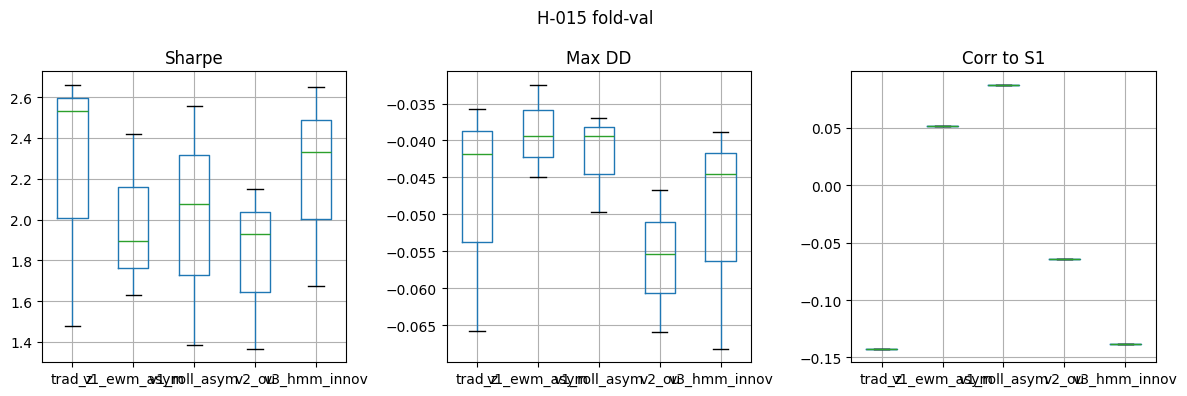

median-Sharpe hint (commentary only): trad_z


,ann_sharpe,max_drawdown,corr_to_s1
arm,,,
trad_z,2.533438,-0.041774,-0.142594
v1_ewm_asym,1.896557,-0.039431,0.051955
v1_roll_asym,2.073762,-0.039408,0.087868
v2_ou,1.927182,-0.055350,-0.064380
v3_hmm_innov,2.328947,-0.044539,-0.138412


In [6]:
plot_fold_boxplots(fold_df, title="H-015 fold-val")
plt.show()
print("median-Sharpe hint (commentary only):", median_sharpe_hint(fold_df))
fold_df.groupby("arm")[["ann_sharpe", "max_drawdown", "corr_to_s1"]].median()


## 6. Type `ENTRY_STAR` then save


In [7]:
ENTRY_STAR = "trad_z"  # TODO set after review — do not use argmax / median Sharpe
require_star("ENTRY_STAR", ENTRY_STAR)
stack["ENTRY_STAR"] = ENTRY_STAR
save_star_stack(STAR_PATH, stack)
print("wrote", STAR_PATH)


wrote C:\Users\User\Desktop\ML Algorithmic Trading\Portfolio 26\trading_portfolio\04_backtest\s2_coint\artifacts\s2_star_stack.json


## 7. Sealed OOS once


In [8]:
require_star("ENTRY_STAR", ENTRY_STAR)
oos_cfg = config_from_stack(load_star_stack(STAR_PATH))
oos = run_s2_backtest(oos_panel, oos_cfg, s1_weekly=s1_weekly)
print(oos.metrics)
write_tearsheet_pdf(tearsheet_path("H-015", str(ENTRY_STAR)), oos.returns, title="H-015 sealed OOS")
print("tearsheet", tearsheet_path("H-015", str(ENTRY_STAR)))


{'ann_sharpe': 1.8695943110981526, 'max_drawdown': -0.053693752313681564, 'n_days': 665, 'corr_to_s1': -0.08816370223902777}
tearsheet C:\Users\User\Desktop\ML Algorithmic Trading\Portfolio 26\trading_portfolio\04_backtest\s2_coint\artifacts\H-015_trad_z.pdf


## 8. Notes for next hyp


All research knobs are now typed. A future live `s2_strategy.py` can hardcode this recipe; do not add it in this program.
